In [1]:
!pip install opencv-contrib-python -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import os
import csv
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [3]:
DATASET_PATH = r"C:\Users\user\Desktop\6th sem\AI LAB\Project\train"

all_files = [f for f in os.listdir(DATASET_PATH) 
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Extract unique names
all_names = sorted(set(f.split('.')[0] for f in all_files))

print(f"Total images : {len(all_files)}")
print(f"Total people : {len(all_names)}")
print(f"Names        : {all_names}")

# Images per person
for name in all_names:
    count = sum(1 for f in all_files if f.split('.')[0] == name)
    print(f"  {name}: {count} images")

Total images : 1005
Total people : 10
Names        : ['Abir', 'Fahim', 'Hemel', 'Nipa', 'Rupak', 'Sabiqul', 'Shepon', 'Tama', 'Tamim', 'Tarup']
  Abir: 101 images
  Fahim: 101 images
  Hemel: 101 images
  Nipa: 101 images
  Rupak: 101 images
  Sabiqul: 101 images
  Shepon: 98 images
  Tama: 100 images
  Tamim: 100 images
  Tarup: 101 images


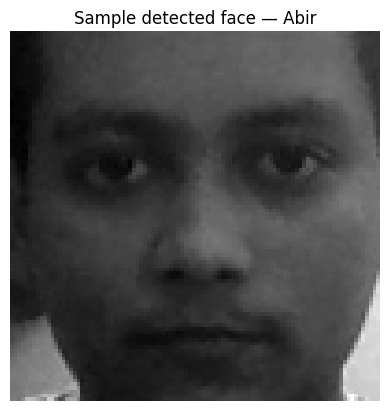

In [4]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def detect_and_crop_face(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    if len(faces) == 0:
        return None
    # Pick the largest face found
    x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
    face = gray[y:y+h, x:x+w]
    return cv2.resize(face, (100, 100))

# Quick test on one image
sample_path = os.path.join(DATASET_PATH, all_files[0])
result = detect_and_crop_face(sample_path)

if result is not None:
    plt.imshow(result, cmap='gray')
    plt.title(f"Sample detected face — {all_files[0].split('.')[0]}")
    plt.axis('off')
    plt.show()
else:
    print("❌ No face detected in sample — check your path or image quality")

In [5]:
X = []
y = []
label_map = {}    # name  → number
reverse_map = {}  # number → name
skipped = []

for idx, name in enumerate(all_names):
    label_map[name] = idx
    reverse_map[idx] = name

for img_file in all_files:
    name = img_file.split('.')[0]
    img_path = os.path.join(DATASET_PATH, img_file)
    face = detect_and_crop_face(img_path)
    
    if face is None:
        skipped.append(img_file)
        continue
    
    X.append(face)
    y.append(label_map[name])

print(f"✅ Loaded  : {len(X)} faces")
print(f"⚠️  Skipped : {len(skipped)} images (no face detected)")
print(f"👤 People  : {len(label_map)}")

✅ Loaded  : 985 faces
⚠️  Skipped : 20 images (no face detected)
👤 People  : 10


In [6]:
X_arr = np.array(X)
y_arr = np.array(y)

indices = list(range(len(X_arr)))
train_idx, test_idx, y_train, y_test = train_test_split(
    indices, y_arr,
    test_size=0.2,
    random_state=42,
    stratify=y_arr      # ensures every person appears in both splits
)

X_train = [X_arr[i] for i in train_idx]
X_test  = [X_arr[i] for i in test_idx]

recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(X_train, np.array(y_train))

recognizer.save("attendance_model.yml")
print(f"✅ Model trained on {len(X_train)} images")
print(f"📝 Test set has {len(X_test)} images")
print("💾 Saved as attendance_model.yml")

✅ Model trained on 788 images
📝 Test set has 197 images
💾 Saved as attendance_model.yml


✅ Accuracy: 197/197 = 100.00%


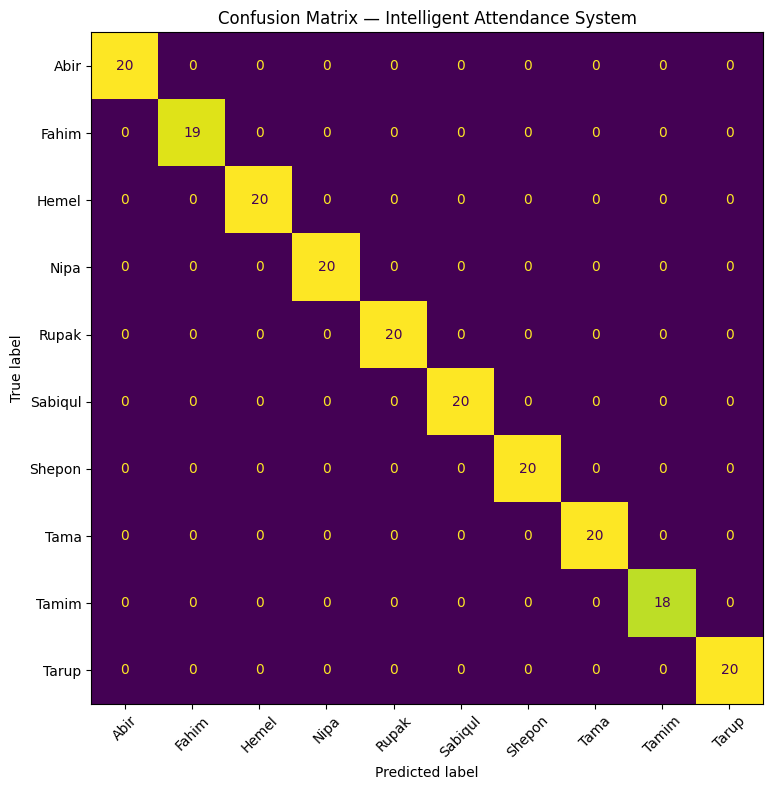


Classification Report:
              precision    recall  f1-score   support

        Abir       1.00      1.00      1.00        20
       Fahim       1.00      1.00      1.00        19
       Hemel       1.00      1.00      1.00        20
        Nipa       1.00      1.00      1.00        20
       Rupak       1.00      1.00      1.00        20
     Sabiqul       1.00      1.00      1.00        20
      Shepon       1.00      1.00      1.00        20
        Tama       1.00      1.00      1.00        20
       Tamim       1.00      1.00      1.00        18
       Tarup       1.00      1.00      1.00        20

    accuracy                           1.00       197
   macro avg       1.00      1.00      1.00       197
weighted avg       1.00      1.00      1.00       197



In [7]:
y_pred = []

for face in X_test:
    label, confidence = recognizer.predict(face)
    y_pred.append(label)

correct = sum(p == t for p, t in zip(y_pred, y_test))
print(f"✅ Accuracy: {correct}/{len(y_test)} = {correct/len(y_test)*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = [reverse_map[i] for i in range(len(all_names))]

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix — Intelligent Attendance System")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

In [8]:
ATTENDANCE_FILE = "attendance.csv"

def mark_attendance(name):
    now = datetime.now()
    date_str = now.strftime("%Y-%m-%d")
    time_str = now.strftime("%H:%M:%S")
    
    already_marked = False
    if os.path.exists(ATTENDANCE_FILE):
        with open(ATTENDANCE_FILE, 'r') as f:
            for row in csv.reader(f):
                if len(row) >= 2 and row[0] == name and row[1] == date_str:
                    already_marked = True
                    break
    
    if not already_marked:
        with open(ATTENDANCE_FILE, 'a', newline='') as f:
            csv.writer(f).writerow([name, date_str, time_str])
        print(f"✅ Marked: {name} at {time_str}")
    else:
        print(f"ℹ️  Already marked today: {name}")

In [12]:
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.read("attendance_model.yml")

CONFIDENCE_THRESHOLD = 80
COOLDOWN_SECONDS = 5
last_marked = {}

cap = cv2.VideoCapture(0)
print("📷 Webcam started. Press Q to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    
    for (x, y, w, h) in faces:
        face_roi = cv2.resize(gray[y:y+h, x:x+w], (100, 100))
        label, confidence = recognizer.predict(face_roi)
        
        if confidence < CONFIDENCE_THRESHOLD:
            name = reverse_map[label]
            color = (0, 255, 0)
            text = f"{name}  ({confidence:.1f})"
            
            now = datetime.now()
            if name not in last_marked or (now - last_marked[name]).seconds >= COOLDOWN_SECONDS:
                mark_attendance(name)
                last_marked[name] = now
        else:
            color = (0, 0, 255)
            text = f"Unknown  ({confidence:.1f})"
        
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
        cv2.putText(frame, text, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    
    cv2.imshow("Intelligent Attendance System", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

📷 Webcam started. Press Q to quit.
✅ Marked: Tama at 12:00:17
ℹ️  Already marked today: Tama
